# Funding Analysis

`Overview`
This notebook focuses on analyzing EU Horizon funding data:
- Exploring funding distribution across countries
- Analyzing research domain allocations
- Visualizing organization participation patterns
- Identifying temporal funding trends
- Creating interactive visualizations for data exploration

`Inputs`
- Processed datasets from `../data/processed/` 

`Outputs`
- Funding analysis visualizations in `../reports/figures/`
- Interactive plots for dashboard integration
- Summary statistics in `../reports/funding_insights.csv`

`Dependencies`
- pandas
- numpy
- matplotlib
- seaborn
- plotly
- geopandas

*Note: This is notebook 2 of the analysis pipeline*

In [1]:
import logging
import sys  
from pathlib import Path
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from tqdm import tqdm  # for a progress bar, pip install tqdm if you don’t have it


# ──────────────────────────────────────────────────────────────────────────────
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s: %(message)s")
logger = logging.getLogger(__name__)


project_root = Path.cwd().parent  # assumes you're in /notebooks
sys.path.append(str(project_root))

           # adjust to your repo root
data_dir     = project_root / 'data' / 'processed'
agg_dir      = project_root / 'data' / 'aggregated'


# ## 2. Load CSVs
# files are in the `data/processed` directory
DATA_DIR = data_dir
files = {
    "projects":      "projects.csv",
    "orgs":          "organizations.csv",
    "proj_orgs":     "project_organizations.csv",
    "topics":        "topics.csv",
    "proj_topics":   "project_topics.csv",
    "sci_voc":       "sci_voc.csv",
    "proj_sci_voc":  "project_sci_voc.csv",
    "deliverables":  "deliverables.csv",
    "publications":  "publications.csv",
}

dfs = {name: pd.read_csv(DATA_DIR / fname, parse_dates=True, low_memory=False)
       for name, fname in files.items()}

# Quick peek
for name, df in dfs.items():
    print(f"=== {name} ===")
    display(df.head(), df.info())
# Merge dataframes

=== projects ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15863 entries, 0 to 15862
Data columns (total 29 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        15863 non-null  int64  
 1   acronym                   15863 non-null  object 
 2   status                    15863 non-null  object 
 3   title                     15863 non-null  object 
 4   start_date                15863 non-null  object 
 5   end_date                  15863 non-null  object 
 6   total_cost                12170 non-null  float64
 7   ec_max_contribution       7791 non-null   float64
 8   ec_signature_date         15862 non-null  object 
 9   framework_programme       15863 non-null  object 
 10  master_call               15863 non-null  object 
 11  sub_call                  15863 non-null  object 
 12  funding_scheme            15863 non-null  object 
 13  nature                    0 non-null      fl

,id,acronym,status,title,start_date,end_date,total_cost,ec_max_contribution,ec_signature_date,framework_programme,...,duration_months,duration_years,n_institutions,coordinator_name,ec_contribution_per_year,total_cost_per_year,field_class,field,sub_field,niche
0,101159220,PvSeroRDT,SIGNED,A point-of-care serological rapid diagnostic t...,2025-02-01,2030-01-31,NaN,NaN,2024-12-09,HORIZON,...,59,4,8,INSTITUT PASTEUR,NaN,NaN,"['natural sciences', 'medical and health scien...","['health sciences', 'biological sciences']","['infectious diseases', 'biochemistry']","['biomolecules', 'malaria']"
1,101096150,BIOBoost,SIGNED,Boosting innovation agencies for bioeconomy va...,2023-02-01,2025-01-31,0.0,500000.0,2022-11-25,HORIZON,...,23,1,8,FBCD AS,500000.0,0.0,['other'],['other'],['other'],['other']
2,101093997,GlycanTrigger,SIGNED,GLYCANS AS MASTER TRIGGERS OF HEALTH TO INTEST...,2023-01-01,2028-12-31,6771571.0,6771571.0,2022-12-05,HORIZON,...,71,5,10,I3S - INSTITUTO DE INVESTIGACAO E INOVACAO EM ...,1354314.2,1354314.2,['natural sciences'],['biological sciences'],['biochemistry'],['biomolecules']
3,101126531,CHIKVAX_CHIM,SIGNED,Late-stage clinical development of Chikungunya...,2023-06-01,2028-11-30,100000000.0,70000000.0,2023-06-15,HORIZON,...,65,5,1,COALITION FOR EPIDEMIC PREPAREDNESS INNOVATIONS,14000000.0,20000000.0,"['natural sciences', 'medical and health scien...","['biological sciences', 'health sciences', 'ba...","['microbiology', 'infectious diseases', 'pharm...","['pharmaceutical drugs', 'virology', 'RNA viru..."
4,101113979,The Oater,CLOSED,The Oater develops a compact machine for hyper...,2023-07-01,2023-12-31,0.0,75000.0,2023-06-05,HORIZON,...,6,0,1,OIY SOLUTIONS GMBH,inf,NaN,"['social sciences', 'natural sciences']","['biological sciences', 'economics and busines...","['ecology', 'internet', 'business and manageme...","['ecosystems', 'commerce', 'internet of things']"


None

=== orgs ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101076 entries, 0 to 101075
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   id                   101076 non-null  int64 
 1   name                 101076 non-null  object
 2   short_name           75409 non-null   object
 3   vat_number           85604 non-null   object
 4   sme                  100813 non-null  object
 5   activity_type        101053 non-null  object
 6   street               100771 non-null  object
 7   post_code            100290 non-null  object
 8   city                 100813 non-null  object
 9   country              101063 non-null  object
 10  nuts_code            100798 non-null  object
 11  geolocation          100403 non-null  object
 12  organization_url     61977 non-null   object
 13  contact_form         101076 non-null  object
 14  content_update_date  101076 non-null  object
dtypes: int64(1), object(1

,id,name,short_name,vat_number,sme,activity_type,street,post_code,city,country,nuts_code,geolocation,organization_url,contact_form,content_update_date
0,986872084,Institut Pasteur de Madagascar,IPM,NaN,False,REC,Ambatofotsikely - Avaradoha,101,Antananarivo,MG,MG,"-18.7920779,47.7823214",NaN,https://ec.europa.eu/info/funding-tenders/oppo...,2024-12-24 11:18:48
1,999542806,INSTITUT PASTEUR DE DAKAR,NaN,NaN,False,REC,AVENUE PASTEUR 36,DAKAR,Dakar,SN,SN,"14.693425,-17.447938",NaN,https://ec.europa.eu/info/funding-tenders/oppo...,2024-12-24 11:18:48
2,889740358,ARMAUER HANSEN RESEARCH INSTITUTE,NaN,NaN,False,REC,JIMMA ROAD ALERT COMPOUND,1005,Addis Ababa,ET,ET,"9.0,38.75",NaN,https://ec.europa.eu/info/funding-tenders/oppo...,2024-12-24 11:18:48
3,999912667,LONDON SCHOOL OF HYGIENE AND TROPICAL MEDICINE...,LSHTM,GB233756066,False,HES,KEPPEL STREET,WC1E 7HT,London,UK,UK,"51.5207316,-0.1294867",http://www.lshtm.ac.uk/,https://ec.europa.eu/info/funding-tenders/oppo...,2024-12-24 11:18:48
4,999679964,FOUNDATION FOR INNOVATIVE NEW DIAGNOSTICS,"FIND, the global alliance for diagnostics",NaN,False,OTH,"CAMPUS BIOTECH, CHEMIN DES MINES 9",1202,Geneve,CH,CH013,"46.221901,6.148001732215738",http://www.finddiagnostics.org/,https://ec.europa.eu/info/funding-tenders/oppo...,2024-12-24 11:18:48


...

,id,project_id,title,deliverable_type,description,url,collection,content_update_date
0,101071179_10_DELIVHORIZON,101071179,Technical/scientific review meeting 2 documents,"Documents, reports",Draft agenda and presentations,https://ec.europa.eu/research/participants/doc...,Project deliverable,2025-02-03 17:40:48
1,101072491_9_DELIVHORIZON,101072491,MIRELAI project website,"Websites, patent fillings, videos etc.",MIRELAI project website,https://ec.europa.eu/research/participants/doc...,Project deliverable,2025-02-26 08:02:37
2,101066116_3_DELIVHORIZON,101066116,"Communication, Dissemination & Outreach Plan","Documents, reports",The plan describes the planned measures to max...,https://ec.europa.eu/research/participants/doc...,Project deliverable,2025-02-03 17:40:42
3,101064988_11_DELIVHORIZON,101064988,SINFONICA Knowledge map creation and System Ar...,"Documents, reports",The deliverable will be the output of Tasks 4....,https://ec.europa.eu/research/participants/doc...,Project deliverable,2025-02-03 17:40:44
4,101071179_51_DELIVHORIZON,101071179,Report on Portfolio activities 01,"Documents, reports",The report will present the collaboration acti...,https://ec.europa.eu/research/participants/doc...,Project deliverable,2025-02-03 17:40:44


None

=== publications ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24150 entries, 0 to 24149
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   id                   24150 non-null  object
 1   project_id           24150 non-null  int64 
 2   title                24150 non-null  object
 3   is_published_as      24150 non-null  object
 4   authors              24075 non-null  object
 5   journal_title        22051 non-null  object
 6   journal_number       10528 non-null  object
 7   published_year       24150 non-null  int64 
 8   published_pages      8 non-null      object
 9   issn                 17146 non-null  object
 10  isbn                 931 non-null    object
 11  doi                  21857 non-null  object
 12  collection           24150 non-null  object
 13  content_update_date  24150 non-null  object
dtypes: int64(2), object(12)
memory usage: 2.6+ MB


,id,project_id,title,is_published_as,authors,journal_title,journal_number,published_year,published_pages,issn,isbn,doi,collection,content_update_date
0,101040480_113381_PUBLIHORIZON,101040480,The Microwave Rotational Electric Resonance (R...,Peer reviewed articles,"Hamza El Hadki, Kenneth J. Koziol, Oum Keltoum...",Molecules,28,2023,NaN,1420-3049,NaN,10.3390/molecules28083419,Project publication,2025-02-11 11:41:50
1,101040480_113371_PUBLIHORIZON,101040480,The microwave spectra of the conformers of n-b...,Peer reviewed articles,"Susanna L. Stephens, Eléonore Antonelli, Alexa...",Journal of Molecular Spectroscopy,397,2024,NaN,0022-2852,NaN,10.1016/j.jms.2023.111824,Project publication,2025-02-11 11:01:16
2,101040480_113383_PUBLIHORIZON,101040480,Coupled internal rotations and 14N quadrupole ...,Peer reviewed articles,"Mike Barth, Isabelle Kleiner, Ha Vinh Lam Nguyen",The Journal of Chemical Physics,160,2024,NaN,0021-9606,NaN,10.1063/5.0213319,Project publication,2025-02-11 11:40:00
3,101040480_113375_PUBLIHORIZON,101040480,"The Heavy Atom Structure, <i>“cis</i> effect” ...",Peer reviewed articles,"Truong Anh Nguyen, Isabelle Kleiner, Martin Sc...",ChemPhysChem,25,2024,NaN,1439-4235,NaN,10.1002/cphc.202400387,Project publication,2025-02-11 11:11:17
4,101040480_113374_PUBLIHORIZON,101040480,"Structure determination of 2,5-difluorophenol ...",Peer reviewed articles,"K.P. Rajappan Nair, Kevin G. Lengsfeld, Philip...",Journal of Molecular Structure,1321,2024,NaN,0022-2860,NaN,10.1016/j.molstruc.2024.139971,Project publication,2025-02-11 11:04:26


None

In [2]:

# ## 3. Merge & Core Table
# Join project_organizations → projects → organizations
df_core = (
    dfs["proj_orgs"]
    .merge(dfs["projects"][[
        "id","acronym","start_date","end_date","ec_max_contribution","ec_contribution_per_year"
    ]], left_on="project_id", right_on="id", how="left", suffixes=("","_proj"))
    .merge(dfs["orgs"][["id","name","country","sme"]], left_on="organization_id", right_on="id", how="left",
           suffixes=("","_org"))
    .rename(columns={"id":"proj_org_id"})
)

print("Core table shape:", df_core.shape)
print("Core table columns:", df_core.columns.tolist())
display(df_core.sample(5))

Core table shape: (7198684, 19)
Core table columns: ['project_id', 'organization_id', 'role', 'order_index', 'ec_contribution', 'net_ec_contribution', 'total_cost', 'end_of_participation', 'active', 'proj_org_id', 'acronym', 'start_date', 'end_date', 'ec_max_contribution', 'ec_contribution_per_year', 'id_org', 'name', 'country', 'sme']


,project_id,organization_id,role,order_index,ec_contribution,net_ec_contribution,total_cost,end_of_participation,active,proj_org_id,acronym,start_date,end_date,ec_max_contribution,ec_contribution_per_year,id_org,name,country,sme
2350713,101147777,999923240,participant,20,94125.0,94125.0,94125,False,NaN,101147777,CLIMRES,2024-06-01,2027-05-31,NaN,NaN,999923240,UNIVERZA V LJUBLJANI,SI,False
840505,101058636,999997930,thirdParty,1,0.0,78245.0,0,False,NaN,101058636,ABSolEU,2022-06-01,2026-05-31,8078862.0,2692954.0,999997930,CENTRE NATIONAL DE LA RECHERCHE SCIENTIFIQUE CNRS,FR,False
4957105,101162914,999979500,coordinator,1,1500000.0,1500000.0,1500000,False,NaN,101162914,TREAT,2025-01-01,2029-12-31,1500000.0,375000.0,999979500,CONSIGLIO NAZIONALE DELLE RICERCHE,IT,False
1785132,101056760,999984059,participant,4,469720.0,469720.0,469720,False,NaN,101056760,HiPE,2022-11-01,2025-10-31,5481273.0,2740636.5,999984059,FRAUNHOFER GESELLSCHAFT ZUR FORDERUNG DER ANGE...,DE,False
3784676,101069726,999991722,participant,6,304896.0,304896.0,"304896,25",False,NaN,101069726,SEATBELT,2022-07-01,2026-06-30,NaN,NaN,999991722,AGENCIA ESTATAL CONSEJO SUPERIOR DE INVESTIGAC...,ES,False


In [3]:
# ## 4. Basic Stats
# Contribution distribution
print("Net EC Contribution:")
display(df_core["net_ec_contribution"].describe())
print("Gross EC (max) Contribution:")
display(df_core["ec_max_contribution"].describe())

# Count of active projects by year
df_core["start_year"] = pd.to_datetime(df_core["start_date"]).dt.year
df_core["end_year"]   = pd.to_datetime(df_core["end_date"]).dt.year
print("Projects started per year:")
display(df_core.groupby("start_year")["project_id"].nunique())

# --- A) Compute daily_net on df_core ---
df_core["start_date"] = pd.to_datetime(df_core["start_date"])
df_core["end_date"]   = pd.to_datetime(df_core["end_date"])

# Duration in days (minimum 1 day)
df_core["duration_days"] = (df_core["end_date"] - df_core["start_date"]).dt.days.clip(lower=1)

# Daily net contribution
df_core["daily_net"] = df_core["net_ec_contribution"] / df_core["duration_days"]


Net EC Contribution:


count    7.197961e+06
mean     6.216463e+05
std      3.074680e+06
min      0.000000e+00
25%      1.738474e+05
50%      3.175188e+05
75%      6.741325e+05
max      4.326332e+08
Name: net_ec_contribution, dtype: float64

Gross EC (max) Contribution:


count    2.962181e+06
mean     7.940756e+06
std      3.988138e+07
min      4.659400e+04
25%      1.500000e+06
50%      2.812437e+06
75%      5.707393e+06
max      5.494420e+08
Name: ec_max_contribution, dtype: float64

Projects started per year:


start_year
2021      30
2022    3345
2023    5131
2024    4962
2025    2324
2026      71
Name: project_id, dtype: int64

In [8]:
# How many project–org rows have no net_ec contribution?
n_null_net = df_core["net_ec_contribution"].isnull().sum()
n_tot = len(df_core)
print(f"net_ec_contribution is NULL on {n_null_net:,} of {n_tot:,} rows "
      f"({n_null_net/n_tot:.1%})")


# Create a unified contribution column
df_core["ec_use"] = (
    df_core["net_ec_contribution"]
      .fillna(df_core["ec_max_contribution"])  # use gross if net missing
)

# Recompute daily rate off that
df_core["daily_net"] = df_core["ec_use"] / df_core["duration_days"]

print("daily_net stats after fill:")
display(df_core["daily_net"].describe())


net_ec_contribution is NULL on 723 of 7,198,684 rows (0.0%)
daily_net stats after fill:


count    7.198535e+06
mean     4.297554e+02
std      1.816441e+03
min      0.000000e+00
25%      1.643262e+02
50%      2.752294e+02
75%      5.068493e+02
max      2.369295e+05
Name: daily_net, dtype: float64

In [4]:
# --- PREWORK: make sure df_core has start_date/end_date/daily_net computed ---
df_core["start_date"] = pd.to_datetime(df_core["start_date"])
df_core["end_date"]   = pd.to_datetime(df_core["end_date"])
df_core["duration_days"] = (df_core["end_date"] - df_core["start_date"]).dt.days.clip(lower=1)
df_core["daily_net"] = df_core["net_ec_contribution"] / df_core["duration_days"]

# --- 1) Prep the small lookup of quarters once ---
q_periods = pd.period_range(
    df_core["start_date"].min().to_period("Q"),
    df_core["end_date"].max().to_period("Q"),
    freq="Q"
)
df_quarters = pd.DataFrame({
    "quarter": q_periods.astype(str),
    "q_start": q_periods.to_timestamp(),
    "q_end":   q_periods.to_timestamp() + pd.offsets.QuarterEnd(0)
})

# --- 2) Base alloc table with only the columns we need ---
df_alloc = df_core[[
    "organization_id", "project_id", "name", 
    "start_date", "end_date", "daily_net"
]].rename(columns={"name":"org_name"}).reset_index(drop=True)

# --- 3) Process in chunks ---
results = []
chunksize = 300_000  # adjust downward if you still hit MemoryError

for lo in tqdm(range(0, len(df_alloc), chunksize)):
    chunk = df_alloc.iloc[lo:lo+chunksize].copy()
    # lightweight cross-join via a dummy key
    chunk["_tmp"]      = 1
    df_quarters["_tmp"] = 1

    df_x = chunk.merge(df_quarters, on="_tmp").drop("_tmp", axis=1)

    # filter to periods that overlap
    mask = (df_x["start_date"] <= df_x["q_end"]) & (df_x["end_date"] >= df_x["q_start"])
    df_x = df_x.loc[mask]

    # compute overlap in days and funding share
    df_x["overlap_start"] = df_x[["start_date","q_start"]].max(axis=1)
    df_x["overlap_end"]   = df_x[["end_date",  "q_end"]].min(axis=1)
    df_x["days_overlap"]  = (df_x["overlap_end"] - df_x["overlap_start"]).dt.days.clip(lower=0)
    df_x["funding_q"]     = df_x["daily_net"] * df_x["days_overlap"]

    # aggregate for this chunk
    agg = (
        df_x
        .groupby(["organization_id","org_name","quarter"], as_index=False)
        ["funding_q"]
        .sum()
    )
    results.append(agg)

# --- 4) Concat & final aggregate to de-duplicate chunks ---
df_q_sum = (
    pd.concat(results, ignore_index=True)
      .groupby(["organization_id","org_name","quarter"], as_index=False)
      ["funding_q"]
      .sum()
)

print("Quarterly totals ready:", df_q_sum.shape)
print(df_q_sum.head())

100%|██████████| 24/24 [01:12<00:00,  3.03s/it]


Quarterly totals ready: (490107, 4)
   organization_id                 org_name quarter  funding_q
0        873166065  Sanofi US Services Inc.  2024Q4        0.0
1        873166065  Sanofi US Services Inc.  2025Q1        0.0
2        873166065  Sanofi US Services Inc.  2025Q2        0.0
3        873166065  Sanofi US Services Inc.  2025Q3        0.0
4        873166065  Sanofi US Services Inc.  2025Q4        0.0


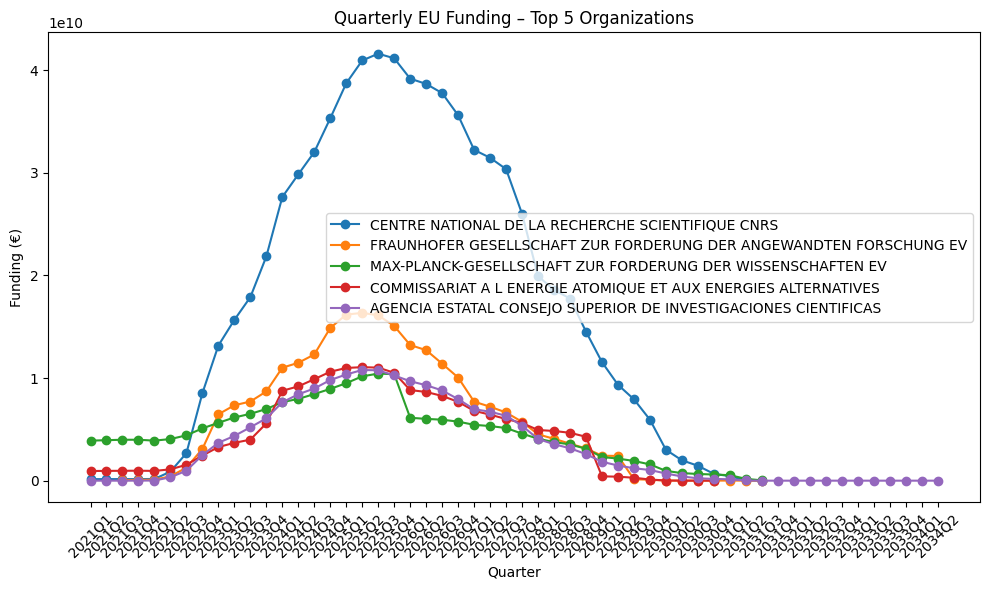

In [5]:
# ## 6. Plotting Examples
# Pick top 5 orgs by total funding
top_orgs = (
    df_q_sum.groupby("org_name")["funding_q"]
    .sum()
    .nlargest(5)
    .index
    .tolist()
)

plt.figure(figsize=(10,6))
for org in top_orgs:
    subset = df_q_sum[df_q_sum["org_name"]==org]
    plt.plot(subset["quarter"], subset["funding_q"], marker="o", label=org)
plt.legend()
plt.title("Quarterly EU Funding – Top 5 Organizations")
plt.xlabel("Quarter")
plt.ylabel("Funding (€)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
y_periods = pd.period_range(df_core.start_date.min().to_period("A"),
                            df_core.end_date.max().to_period("A"),
                            freq="A")
df_years = pd.DataFrame({
  "year":    y_periods.astype(str),
  "y_start": y_periods.to_timestamp(how="start"),
  "y_end":   y_periods.to_timestamp(how="end")
})


# --- 2) Base alloc table with only the columns we need ---
df_alloc = df_core[[
    "organization_id", "project_id", "name", 
    "start_date", "end_date", "daily_net"
]].rename(columns={"name":"org_name"}).reset_index(drop=True)

# --- 3) Process in chunks ---
results = []
chunksize = 300_000  # adjust downward if you still hit MemoryError

for lo in tqdm(range(0, len(df_alloc), chunksize)):
    chunk = df_alloc.iloc[lo:lo+chunksize].copy()
    # lightweight cross-join via a dummy key
    chunk["_tmp"]      = 1
    df_years["_tmp"] = 1

    df_x = chunk.merge(df_years, on="_tmp").drop("_tmp", axis=1)

    # filter to periods that overlap
    mask = (df_x["start_date"] <= df_x["y_end"]) & (df_x["end_date"] >= df_x["y_start"])
    df_x = df_x.loc[mask]

    # compute overlap in days and funding share
    df_x["overlap_start"] = df_x[["start_date","y_start"]].max(axis=1)
    df_x["overlap_end"]   = df_x[["end_date",  "y_end"]].min(axis=1)
    df_x["days_overlap"]  = (df_x["overlap_end"] - df_x["overlap_start"]).dt.days.clip(lower=0)
    df_x["funding_y"]     = df_x["daily_net"] * df_x["days_overlap"]

    # aggregate for this chunk
    agg = (
        df_x
        .groupby(["organization_id","org_name","year"], as_index=False)
        ["funding_y"]
        .sum()
    )
    results.append(agg)

# --- 4) Concat & final aggregate to de-duplicate chunks ---
df_y_sum = (
    pd.concat(results, ignore_index=True)
      .groupby(["organization_id","org_name","year"], as_index=False)
      ["funding_y"]
      .sum()
)

print("Yearly totals ready:", df_y_sum.shape)
print(df_y_sum.head())

100%|██████████| 24/24 [00:20<00:00,  1.15it/s]

Yearly totals ready: (138903, 4)
   organization_id                 org_name  year  funding_y
0        873166065  Sanofi US Services Inc.  2024        0.0
1        873166065  Sanofi US Services Inc.  2025        0.0
2        873166065  Sanofi US Services Inc.  2026        0.0
3        873166065  Sanofi US Services Inc.  2027        0.0
4        873166065  Sanofi US Services Inc.  2028        0.0


In [12]:
# Save the quarterly and yearly aggregates
df_q_sum.to_csv(agg_dir / "quarterly_funding.csv", index=False)
df_y_sum.to_csv(agg_dir / "yearly_funding.csv", index=False)

logger.info("Aggregated funding data saved to CSVs in %s", agg_dir)
logger.info("Done processing and aggregating EU funding data.")

# Sort by quarter (earliest first) then organization, and show first 5 rows
df_q_sum.sort_values(["quarter","organization_id"], ascending=[True,True]).head()

display(df_q_sum.head())
df_q_sum["funding_q"].describe()

2025-05-26 20:30:32,352 INFO: Aggregated funding data saved to CSVs in c:\Users\suley\Desktop\ManaMa\MDA\EU_Horizon_Dashboard\data\aggregated
2025-05-26 20:30:32,361 INFO: Done processing and aggregating EU funding data.


,organization_id,org_name,quarter,funding_q
0,873166065,Sanofi US Services Inc.,2024Q4,0.0
1,873166065,Sanofi US Services Inc.,2025Q1,0.0
2,873166065,Sanofi US Services Inc.,2025Q2,0.0
3,873166065,Sanofi US Services Inc.,2025Q3,0.0
4,873166065,Sanofi US Services Inc.,2025Q4,0.0


count    4.901070e+05
mean     9.032941e+06
std      2.630644e+08
min      0.000000e+00
25%      3.603328e+03
50%      1.932586e+04
75%      1.041416e+05
max      4.159260e+10
Name: funding_q, dtype: float64

Top‐funded organization ID: 999997930 
Name: CENTRE NATIONAL DE LA RECHERCHE SCIENTIFIQUE CNRS


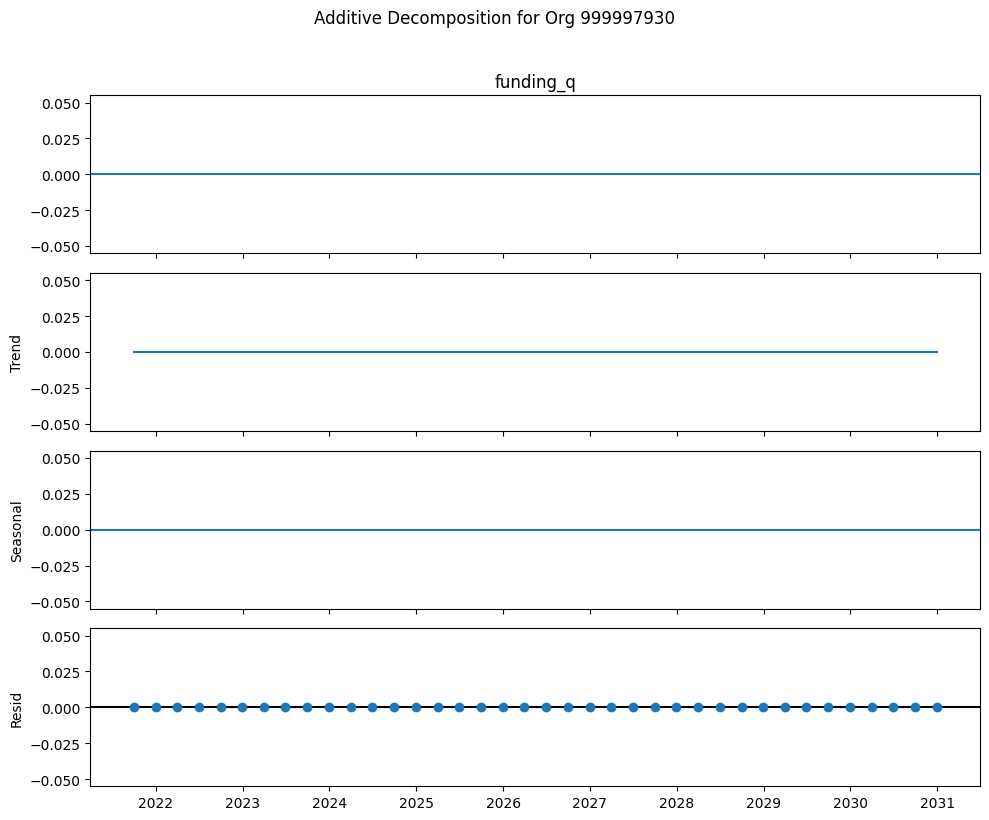

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure we have a datetime index
df_q_sum["quarter_start"] = pd.PeriodIndex(df_q_sum["quarter"], freq="Q").to_timestamp()

# 2.1 Find top‐funded org
top_org = (
    df_q_sum.groupby("organization_id")["funding_q"]
    .sum()
    .idxmax()
)
print("Top‐funded organization ID:", top_org,
      "\nName:", df_q_sum[df_q_sum.organization_id==top_org]["org_name"].iat[0])

# 2.2 Build its time series
ts = (
    df_q_sum[df_q_sum["organization_id"] == top_org]
    .set_index("quarter_start")["funding_q"]
    .asfreq("Q")
    .fillna(0)
)

# 2.3 Decompose (additive, 4‐quarter seasonality)
result = seasonal_decompose(ts, model="additive", period=4)

# 2.4 Plot
fig = result.plot()
fig.set_size_inches(10, 8)
plt.suptitle(f"Additive Decomposition for Org {top_org}", y=1.02)
plt.tight_layout()
plt.show()
